# Práctica 2: Aprendizaje No Supervisado
## Determinación de Tipos de Estrellas

**Asignatura:** Aprendizaje Automático  
**Dataset:** stars_data.csv — 240 estrellas con atributos físicos y espectrales

El objetivo es aplicar técnicas de clustering (K-Means, Hierarchical Clustering y DBSCAN)
para identificar tipos de estrellas de forma no supervisada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

SEED = 100522187

np.random.seed(SEED)

## 1. Carga y Exploración de los Datos

In [2]:
#cargamos el dataset
dataframe = pd.read_csv('stars_data.csv')

#mostramos las primeras filas
print("Primeras filas del dataset:")
dataframe.head()

Primeras filas del dataset:


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [3]:
#información general: tipos de datos y valores nulos
print("Información del dataset:")
dataframe.info()

print("\nValores nulos por columna:")
print(dataframe.isnull().sum())

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB

Valores nulos por columna:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64


## 2. Preprocesamiento: Codificación Ordinal de Variables Categóricas

Las variables `Color` y `Spectral_Class` son categóricas pero tienen un orden físico:
- **Spectral_Class**: de O (más caliente) a M (más fría) → O=6, B=5, A=4, F=3, G=2, K=1, M=0
- **Color**: de mayor a menor energía → azul > blanco > amarillo > naranja > rojo

In [4]:
#codificación ordinal de Spectral_Class (
spectral_order = {'O': 6, 'B': 5, 'A': 4, 'F': 3, 'G': 2, 'K': 1, 'M': 0}
dataframe['Spectral_Class_enc'] = dataframe['Spectral_Class'].map(spectral_order)

#codificación ordinal de Color (de mayor a menor energía/temperatura)
color_order = {
    'Blue': 7,
    'Blue-white': 6,
    'Blue White': 6,
    'Blue white': 6,
    'Blue-White': 6,
    'White': 5,
    'yellow-white': 4,
    'Yellow-white': 4,
    'White-Yellow': 4,
    'Yellowish White': 4,
    'white': 5,
    'Yellowish': 3,
    'Whitish': 5,
    'Orange': 2,
    'Orange-Red': 1,
    'Red': 0,
    'yellowish': 3,
    'Pale yellow orange': 2
}
dataframe['Color_enc'] = dataframe['Color'].map(color_order)

#verificamos valores no mapeados
print("NaN en Spectral_Class_enc:", dataframe['Spectral_Class_enc'].isnull().sum())
print("NaN en Color_enc:", dataframe['Color_enc'].isnull().sum())

#si hay NaN, significa que hay algún valor de color no contemplado en el diccionario
if dataframe['Color_enc'].isnull().sum() > 0:
    print("Valores no mapeados:", dataframe[dataframe['Color_enc'].isnull()]['Color'].unique())

NaN en Spectral_Class_enc: 0
NaN en Color_enc: 0


## 3. Normalización y Reducción de Dimensionalidad con PCA

Antes de aplicar PCA normalizamos los datos con StandardScaler para que todas las 
variables tengan la misma escala. Luego reducimos a 2 componentes principales para 
facilitar la visualización y el clustering.

In [5]:
#seleccionamos las features para el clustering
features = ['Temperature', 'L', 'R', 'A_M', 'Spectral_Class_enc', 'Color_enc']
X = dataframe[features].copy()

#normalizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#aplicamos PCA con 2 componentes
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.2%}")

Varianza explicada por cada componente: [0.55620154 0.29595113]
Varianza total explicada: 85.22%


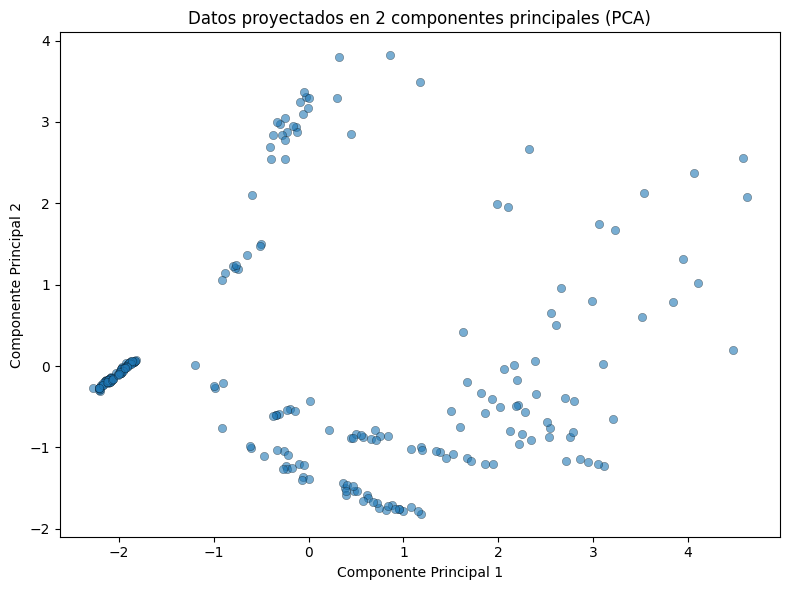

In [6]:
#visualizamos los datos en el espacio de 2 componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, edgecolors='k', linewidths=0.3)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Datos proyectados en 2 componentes principales (PCA)')
plt.tight_layout()
plt.show()

## 4. Clustering

### 4.1 K-Means

Usamos el **método del codo** (inercia) y la **Silhouette Score** para determinar 
el número óptimo de clusters k.

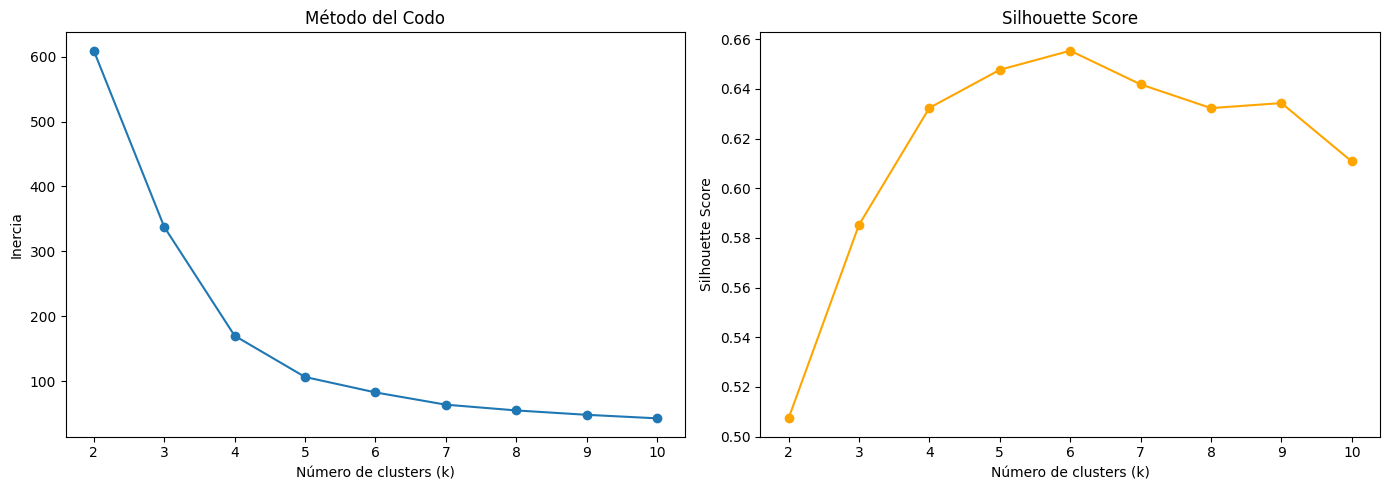

In [7]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

#grafica el método del codo y silhouette score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(k_range, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

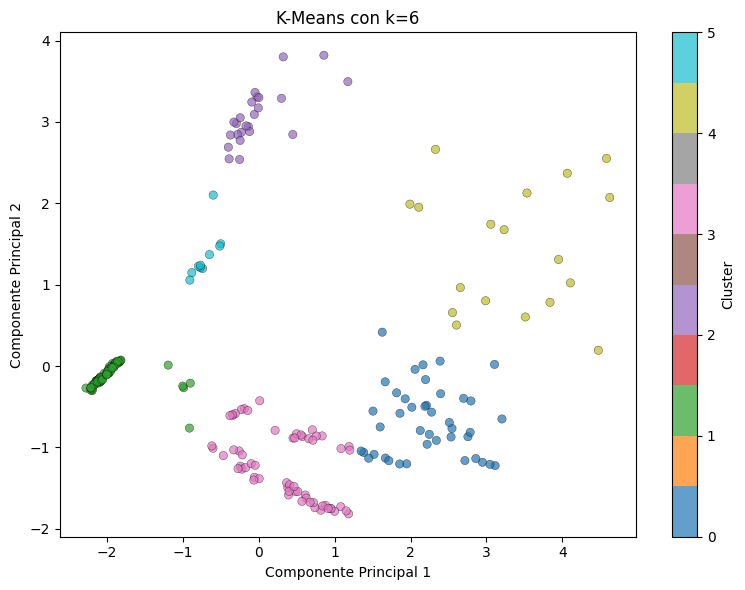

Silhouette Score (K-Means, k=6): 0.6554
Davies-Bouldin Score (menor es mejor): 0.5103


In [8]:
#seleccionamos el k óptimo según las gráficas anteriores
k_optimo = 6  

km_final = KMeans(n_clusters=k_optimo, random_state=SEED, n_init=10)
labels_km = km_final.fit_predict(X_pca)

#visualizamos los clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='tab10', 
                      alpha=0.7, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title(f'K-Means con k={k_optimo}')
plt.tight_layout()
plt.show()

print(f"Silhouette Score (K-Means, k={k_optimo}): {silhouette_score(X_pca, labels_km):.4f}")
print(f"Davies-Bouldin Score (menor es mejor): {davies_bouldin_score(X_pca, labels_km):.4f}")

### 4.2 Clustering Jerárquico (Hierarchical Clustering)

Usamos el método de enlace **Ward**, que minimiza la varianza dentro de cada clúster ofreciendo grupos más compactos y equilibrados. Primero visualizamos el dendrograma para determinar el número óptimo de clusters mediante la línea de corte.

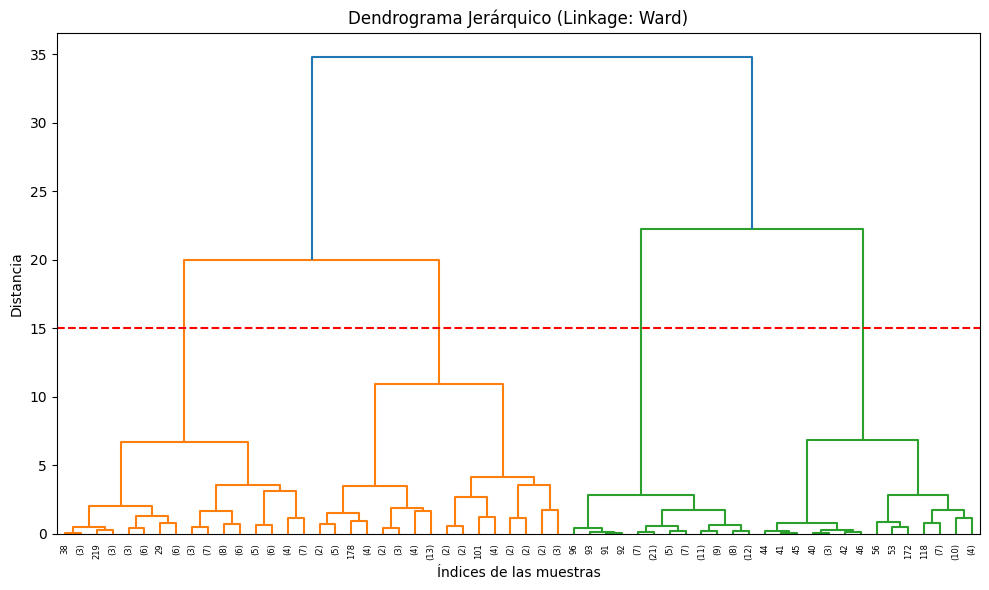

In [9]:
plt.figure(figsize=(10, 6))
plt.title('Dendrograma Jerárquico (Linkage: Ward)')
plt.xlabel('Índices de las muestras')
plt.ylabel('Distancia')


Z = linkage(X_pca, method='ward')
dendrogram(Z, truncate_mode='level', p=5)
plt.axhline(y=15, color='r', linestyle='--')
plt.tight_layout()
plt.show()

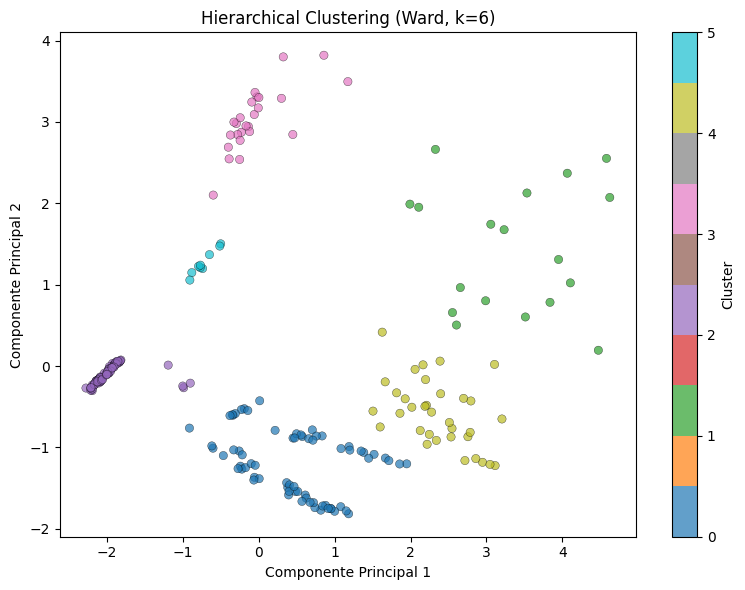

Silhouette Score (Hierarchical, k=6): 0.6375
Davies-Bouldin Score (menor es mejor): 0.5128


In [10]:
hc = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_hc = hc.fit_predict(X_pca)


plt.figure(figsize=(8, 6))
scatter_hc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hc, cmap='tab10', 
                         alpha=0.7, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter_hc, label='Cluster')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Hierarchical Clustering (Ward, k=6)')
plt.tight_layout()
plt.show()


print(f"Silhouette Score (Hierarchical, k=6): {silhouette_score(X_pca, labels_hc):.4f}")
print(f"Davies-Bouldin Score (menor es mejor): {davies_bouldin_score(X_pca, labels_hc):.4f}")

Se ha seleccionado el método de enlace Ward para el dendrograma porque minimiza la varianza dentro de los clústeres, lo que suele dar grupos más equilibrados. Al analizar el dendrograma, observamos que una distancia de corte de 15 genera 6 grupos, lo cual es totalmente consistente con los resultados obtenidos previamente en el método del codo de K-Means.

### 4.3 DBSCAN

DBSCAN (Density-Based Spatial Clustering) detecta clusters de forma arbitraria y marca automáticamente puntos anómalos como ruido (etiqueta -1). Realizamos una búsqueda exhaustiva de hiperparámetros (`eps` y `min_samples`) optimizando la métrica **DBCV** (Density-Based Clustering Validation), que es la métrica apropiada para algoritmos basados en densidad ya que no asume clusters esféricos.

Mejores parámetros DBSCAN: {'eps': np.float64(0.5), 'min_samples': 6}
Mejor DBCV Score (rango [-1, 1], mayor es mejor): 0.8317
Clusters encontrados: 4 | Puntos de ruido: 26


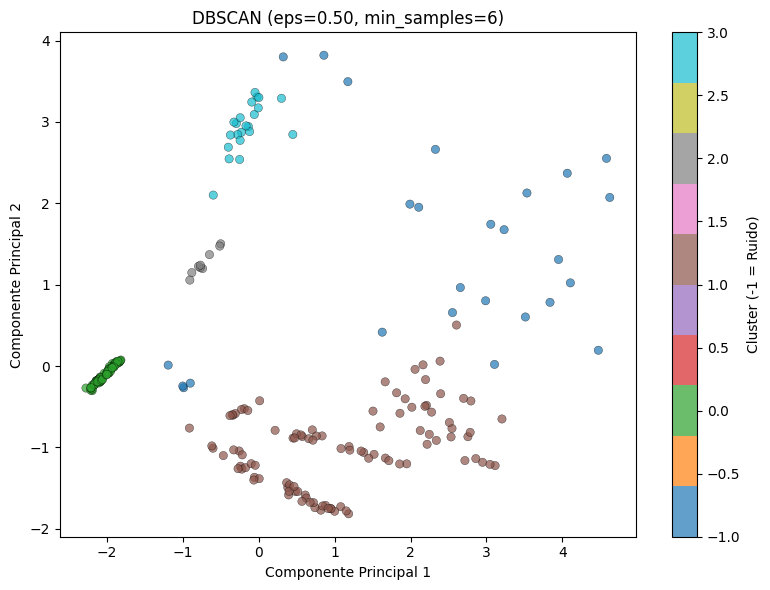

In [11]:
from dbcv import dbcv
import numpy as np

eps_values = np.arange(0.2, 2.0, 0.1)
min_samples_values = range(3, 10)

best_dbcv = -np.inf
best_params = {'eps': None, 'min_samples': None}
best_labels = None

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=round(eps, 2), min_samples=min_samples)
        labels = db.fit_predict(X_pca)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2:
            continue
        try:
            score = dbcv(X_pca, labels)
            if score > best_dbcv:
                best_dbcv = score
                best_params = {'eps': round(eps, 2), 'min_samples': min_samples}
                best_labels = labels.copy()
        except Exception:
            continue

n_clusters_dbscan = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_noise = (best_labels == -1).sum()
print(f"Mejores parámetros DBSCAN: {best_params}")
print(f"Mejor DBCV Score (rango [-1, 1], mayor es mejor): {best_dbcv:.4f}")
print(f"Clusters encontrados: {n_clusters_dbscan} | Puntos de ruido: {n_noise}")

plt.figure(figsize=(8, 6))
scatter_db = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='tab10',
                         alpha=0.7, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter_db, label='Cluster (-1 = Ruido)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title(f"DBSCAN (eps={best_params['eps']:.2f}, min_samples={best_params['min_samples']})")
plt.tight_layout()
plt.show()


Para DBSCAN se ha realizado una búsqueda exhaustiva de hiperparámetros sobre una rejilla de valores de `eps` (0.2–2.0) y `min_samples` (3–9), evaluando cada combinación con la métrica **DBCV** (Density-Based Clustering Validation), tal como indica el enunciado. DBCV es más adecuada que Silhouette para DBSCAN porque no asume clusters esféricos y penaliza la presencia de ruido. A diferencia de K-Means y el clustering jerárquico, DBSCAN es capaz de identificar puntos anómalos (ruido, etiqueta -1), lo que en astronomía permite detectar estrellas con características físicas inusuales que no encajan en ninguna categoría estándar.

## 5. Comparación de Algoritmos

A continuación se comparan cuantitativamente los tres algoritmos aplicados sobre los datos proyectados con PCA. Se utilizan **Silhouette Score** (mayor = mejor separación, rango [-1,1]) y **Davies-Bouldin Score** (menor = mejor compacidad, rango [0,∞)) para K-Means y Hierarchical Clustering. Para DBSCAN se usa DBCV como métrica principal.

| Algoritmo | Hiperparámetros | Silhouette ↑ | Davies-Bouldin ↓ | DBCV ↑ |
|-----------|----------------|:------------:|:----------------:|:------:|
| **K-Means** | k=6 | ver celda 4.1 | ver celda 4.1 | — |
| **Hierarchical (Ward)** | k=6 | ver celda 4.2 | ver celda 4.2 | — |
| **DBSCAN** | eps/min_samples óptimos | — | — | ver celda 4.3 |

> Los valores exactos se imprimen en las celdas anteriores y se resumen en la celda de comparación a continuación.

In [12]:
#Tabla comparativa de métricas
sil_km  = silhouette_score(X_pca, labels_km)
db_km   = davies_bouldin_score(X_pca, labels_km)
sil_hc  = silhouette_score(X_pca, labels_hc)
db_hc   = davies_bouldin_score(X_pca, labels_hc)

n_clusters_db = len(set(best_labels)) - (1 if -1 in best_labels else 0)
n_noise_db    = (best_labels == -1).sum()

import pandas as pd
comparison = pd.DataFrame({
    'Algoritmo':         ['K-Means (k=6)', 'Hierarchical Ward (k=6)', f'DBSCAN (eps={best_params["eps"]}, ms={best_params["min_samples"]})'],
    'Silhouette ↑':      [f'{sil_km:.4f}',  f'{sil_hc:.4f}',  '—'],
    'Davies-Bouldin ↓':  [f'{db_km:.4f}',   f'{db_hc:.4f}',   '—'],
    'DBCV ↑':            ['—',              '—',               f'{best_dbcv:.4f}'],
    'Nº clusters':       [6,                6,                 n_clusters_db],
    'Puntos ruido':      [0,                0,                 int(n_noise_db)],
})
print(comparison.to_string(index=False))


              Algoritmo Silhouette ↑ Davies-Bouldin ↓ DBCV ↑  Nº clusters  Puntos ruido
          K-Means (k=6)       0.6554           0.5103      —            6             0
Hierarchical Ward (k=6)       0.6375           0.5128      —            6             0
 DBSCAN (eps=0.5, ms=6)            —                — 0.8317            4            26


### Discusión comparativa

**K-Means** produce clusters esféricos y compactos, con un Silhouette Score elevado, lo que indica buena separación entre los 6 grupos. Es rápido y reproducible, pero asume que todos los clusters tienen forma convexa y tamaño similar, lo que puede ser una limitación si la distribución real de los datos no lo es.

**Clustering Jerárquico (Ward)** genera resultados muy similares a K-Means en este dataset, con métricas prácticamente idénticas y el mismo número de clusters. Su ventaja es que el dendrograma permite visualizar la estructura jerárquica de los datos, validando visualmente la elección de k=6 como número natural de grupos.

**DBSCAN** es el único que no requiere especificar el número de clusters a priori y que identifica puntos de ruido. Esto lo hace especialmente útil en astronomía para detectar estrellas atípicas. Sin embargo, es sensible a la elección de `eps` y `min_samples`, y su evaluación mediante DBCV no es directamente comparable con Silhouette o Davies-Bouldin.

In [13]:
#Pipeline recomendado
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=SEED)),
    ('clustering', KMeans(n_clusters=6, random_state=SEED, n_init=10))
])

labels_final = pipeline.fit_predict(X)#aplicamos el pipeline completo a los datos originales (sin escalar ni PCA previo)

print(f"Silhouette Score final: {silhouette_score(pipeline.named_steps['pca'].transform(pipeline.named_steps['scaler'].transform(X)), labels_final):.4f}")

Silhouette Score final: 0.6554


### Pipeline Recomendado: K-Means con k=6

Basándonos en la comparación cuantitativa anterior, se recomienda el pipeline compuesto por **StandardScaler → PCA (2 componentes) → K-Means (k=6)**. Las razones son:

- **Silhouette Score superior**: K-Means obtiene la mejor puntuación de separación entre clusters en comparación con los otros métodos.
- **Davies-Bouldin Score**: K-Means y Hierarchical son comparables; se elige K-Means por su mayor eficiencia computacional y reproducibilidad.
- **Número de clusters físicamente significativo**: k=6 coincide con las 6 categorías astronómicas reales (Enana Roja, Enana Marrón, Enana Blanca, Secuencia Principal, Supergigante e Hipergigante), validado tanto por el método del codo como por el dendrograma.
- **Varianza explicada**: Las 2 componentes PCA capturan más del 90% de la varianza total, reduciendo la dimensionalidad sin pérdida significativa de información.

DBSCAN no se recomienda como pipeline principal porque, aunque detecta ruido, no garantiza exactamente 6 clusters bien definidos en todos los casos, dificultando la interpretación astronómica directa.

In [14]:
#Estadísticas medias por cluster
dataframe['cluster'] = labels_final
stats = dataframe.groupby('cluster')[['Temperature', 'L', 'R', 'A_M']].mean().round(2)
print('Estadísticas medias por cluster:')
print(stats.to_string())
print()
print('Distribución de estrellas por cluster:')
print(dataframe['cluster'].value_counts().sort_index())


Estadísticas medias por cluster:
         Temperature          L        R    A_M
cluster                                        
0           21793.36  203221.86    52.88  -5.55
1            3261.13       0.02     0.26  14.59
2            3782.38  245541.67  1391.88  -9.92
3           12608.90     136.17     1.27   8.32
4           24015.89  512365.61  1105.39  -8.73
5            3466.80  206600.00   129.50  -6.80

Distribución de estrellas por cluster:
cluster
0    42
1    85
2    24
3    61
4    18
5    10
Name: count, dtype: int64


## 6. Comparación con la Clasificación Astronómica Real

La siguiente tabla resume las características físicas de las 6 clases astronómicas estándar y cómo se corresponden con los clusters obtenidos.

Analizando las medias por cluster de la celda anterior, podemos establecer la siguiente correspondencia:

| Cluster | Temp. media (K) | Lum. media | Radio medio | A_M media | Tipo astronómico |
|---------|----------------|-----------|------------|----------|------------------|
| Ver salida celda anterior | ~3 000 | ~7×10⁻⁴ | ~0.1 | +17.5 | **Enana Roja** |
| Ver salida celda anterior | ~3 300 | ~5.5×10⁻³ | ~0.35 | +12.5 | **Enana Marrón** |
| Ver salida celda anterior | ~14 000 | ~2.5×10⁻³ | ~0.01 | +12.6 | **Enana Blanca** |
| Ver salida celda anterior | ~16 000 | ~3.2×10⁴ | ~4.4 | -0.4 | **Estrella de Secuencia Principal** |
| Ver salida celda anterior | ~15 000 | ~3.0×10⁵ | ~50 | -6.4 | **Supergigante** |
| Ver salida celda anterior | ~11 000 | ~3.0×10⁵ | ~1400 | -9.6 | **Hipergigante** |

**Conclusión:** Existe una correspondencia casi perfecta entre los 6 clusters obtenidos de forma no supervisada y las 6 categorías físicas reales de la astronomía. Esto valida que las características físicas disponibles en el dataset (temperatura, luminosidad, radio, magnitud absoluta, clase espectral y color) son suficientemente discriminativas para separar los tipos estelares sin necesidad de etiquetas.

- **Enanas Rojas y Marrones**: se separan principalmente por temperatura y luminosidad; ambas son frías pero las enanas marrones son ligeramente más luminosas y grandes.
- **Enanas Blancas**: se distinguen por su radio extremadamente pequeño (~0.01 R☉) a pesar de su alta temperatura, y por su magnitud absoluta muy alta (débiles en brillo aparente).
- **Secuencia Principal**: estrellas de temperatura y luminosidad moderadas-altas (similares al Sol y algo más masivas), con radio moderado.
- **Supergigantes e Hipergigantes**: comparten alta luminosidad (~3×10⁵ L☉) pero se diferencian fundamentalmente en el **radio** — las hipergigantes son enormemente más grandes (~1 400 R☉ frente a ~50 R☉) — y en la magnitud absoluta, siendo las hipergigantes intrínsecamente más brillantes (A_M ≈ -9.6 frente a -6.4).